# 2.0 Preparacion de los Datos

Corresponde a la seccion 7.3 de la monografia. Segmenta las 24 senales en
ventanas de 4096 muestras, extrae las 5 caracteristicas seleccionadas
(RMS, skewness, kurtosis, factor de cresta, centroide espectral) y
construye:

1. La tabla minable completa (994 ventanas) para la comparacion inicial
   de modelos (secciones 7.4.1-7.4.5, sobre las 4 particiones originales).
2. La separacion en conjunto de ajuste (18 archivos) y test independiente
   (6 archivos), respondiendo a la observacion del docente sobre la
   ausencia de un test posterior a la seleccion del modelo.

La logica de segmentacion/extraccion vive en `rodamientos_module.features`;
la logica de particionado en `rodamientos_module.particionado`.

In [1]:
import sys
sys.path.insert(0, "..")

from rodamientos_module import config
from rodamientos_module.dataset import CargadorCWRU
from rodamientos_module.features import ConstructorTablaModelado
from rodamientos_module.particionado import ParticionadorPorArchivo

cargador = CargadorCWRU(config.DIR_DATOS_RAW, config.ARCHIVOS_POR_CLASE)
registros = cargador.cargar_todos()
print(f"Archivos cargados: {len(registros)}")

Archivos cargados: 24


## 7.3.2 Segmentacion de las senales

Ventanas de 4096 muestras (~0.3413 s a 12 kHz), sin solapamiento. Las
muestras finales que no completan una ventana se descartan.

In [2]:
constructor = ConstructorTablaModelado(
    tamano_ventana=config.TAMANO_VENTANA,
    fs=config.FRECUENCIA_MUESTREO,
)

df_modelo_base = constructor.construir(registros)
print(f"Total de ventanas generadas: {len(df_modelo_base)}")
print(f"Tamano de ventana: {config.TAMANO_VENTANA} muestras ({config.TAMANO_VENTANA/config.FRECUENCIA_MUESTREO:.4f} s)")

Total de ventanas generadas: 994
Tamano de ventana: 4096 muestras (0.3413 s)


## 7.3.3 - 7.3.4 Extraccion y verificacion de caracteristicas

Las 5 caracteristicas seleccionadas: RMS, skewness, kurtosis, factor de
cresta y centroide espectral.

In [3]:
df_modelo_base.head()

,archivo,clase,ventana,rms,skewness,kurtosis,factor_cresta,centroide_espectral
0,97.mat,Normal,0,0.076201,-0.094576,-0.108496,3.580932,1115.502083
1,97.mat,Normal,1,0.074014,-0.059872,-0.142167,3.368230,1111.432177
2,97.mat,Normal,2,0.072390,-0.112445,-0.153091,3.103747,1136.622053
3,97.mat,Normal,3,0.072054,-0.073989,-0.241223,3.286134,1117.868596
4,97.mat,Normal,4,0.072785,-0.073225,-0.318430,3.410762,1125.720538


In [4]:
print("Valores faltantes por columna:")
print(df_modelo_base[config.CARACTERISTICAS_MODELO].isna().sum())

print("\nFilas duplicadas:", df_modelo_base.duplicated().sum())

Valores faltantes por columna:
rms                    0
skewness               0
kurtosis               0
factor_cresta          0
centroide_espectral    0
dtype: int64

Filas duplicadas: 0


### Figura 6. Matriz de correlacion entre las caracteristicas temporales y frecuenciales

Para este analisis exploratorio se calcula un conjunto ampliado de
caracteristicas (mas alla de las 5 finales), con el fin de identificar
redundancia entre variables antes de seleccionar el conjunto definitivo
(seccion 7.3.4).

In [5]:
import matplotlib.pyplot as plt
from rodamientos_module.eda import analisis as eda

df_exploratorio = eda.tabla_caracteristicas_exploratorias(
    registros, tamano_ventana=config.TAMANO_VENTANA, fs=config.FRECUENCIA_MUESTREO
)
cols_numericas = ["media", "std", "rms", "min", "max", "pico_pico", "skewness",
                   "kurtosis", "factor_cresta", "centroide_espectral",
                   "frecuencia_rms", "energia_espectral"]
corr = df_exploratorio[cols_numericas].corr()
corr.to_csv(config.DIR_REPORTES_FIGURAS.parent / "tabla_correlacion_exploratoria.csv")
corr.round(2)

,media,std,rms,min,max,pico_pico,skewness,kurtosis,factor_cresta,centroide_espectral,frecuencia_rms,energia_espectral
media,1.00,-0.31,-0.31,0.35,-0.33,-0.34,-0.37,-0.34,-0.35,-0.54,-0.53,-0.22
std,-0.31,1.00,1.00,-0.97,0.98,0.97,0.65,0.46,0.32,0.67,0.64,0.97
rms,-0.31,1.00,1.00,-0.97,0.98,0.97,0.65,0.46,0.32,0.67,0.64,0.97
min,0.35,-0.97,-0.97,1.00,-0.99,-1.00,-0.64,-0.66,-0.51,-0.76,-0.73,-0.90
max,-0.33,0.98,0.98,-0.99,1.00,1.00,0.67,0.63,0.48,0.75,0.73,0.91
pico_pico,-0.34,0.97,0.97,-1.00,1.00,1.00,0.65,0.64,0.50,0.75,0.73,0.91
skewness,-0.37,0.65,0.65,-0.64,0.67,0.65,1.00,0.41,0.40,0.75,0.74,0.54
kurtosis,-0.34,0.46,0.46,-0.66,0.63,0.64,0.41,1.00,0.92,0.75,0.76,0.28
factor_cresta,-0.35,0.32,0.32,-0.51,0.48,0.50,0.40,0.92,1.00,0.69,0.71,0.14
centroide_espectral,-0.54,0.67,0.67,-0.76,0.75,0.75,0.75,0.75,0.69,1.00,1.00,0.50


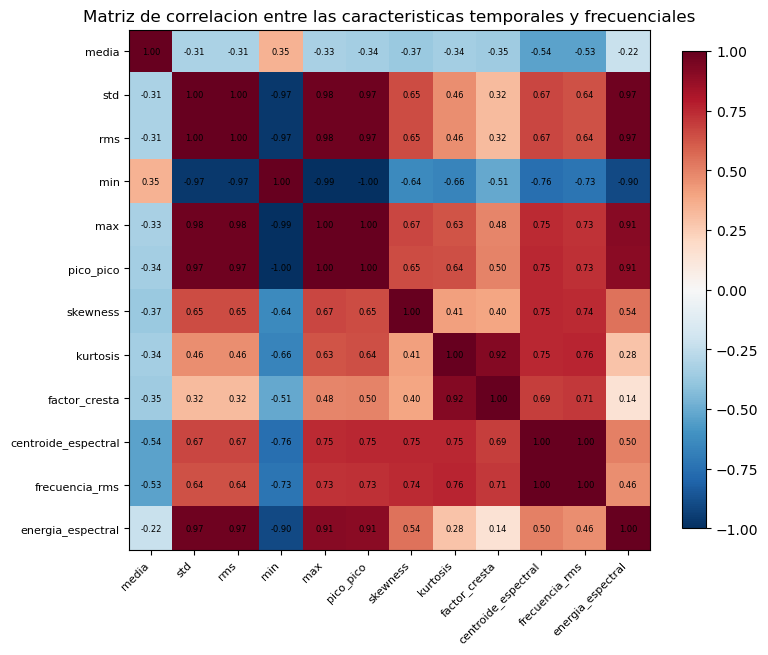

Figura guardada en reports/figures/fig06_matriz_correlacion.png


In [6]:
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(cols_numericas)))
ax.set_yticks(range(len(cols_numericas)))
ax.set_xticklabels(cols_numericas, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(cols_numericas, fontsize=8)
for i in range(len(cols_numericas)):
    for j in range(len(cols_numericas)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=6)
ax.set_title("Matriz de correlacion entre las caracteristicas temporales y frecuenciales")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig("../reports/figures/fig06_matriz_correlacion.png", dpi=150)
plt.show()
print("Figura guardada en reports/figures/fig06_matriz_correlacion.png")

### Figura 7. Distribucion del RMS segun la condicion del rodamiento

A nivel de ventana (994 observaciones), complementando el analisis por
registro de la seccion 7.2.

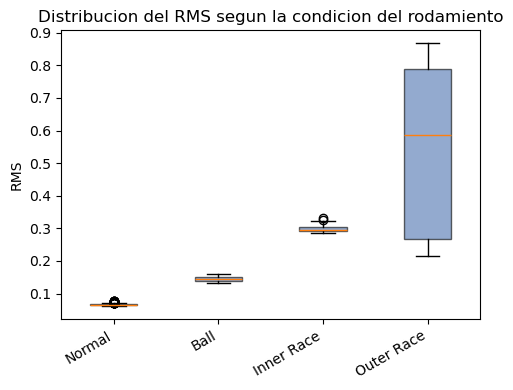

Figura guardada en reports/figures/fig07_boxplot_rms.png


In [7]:
df_modelo_temp = df_modelo_base if "df_modelo_base" in dir() else None
datos_rms_ventana = [
    df_exploratorio.loc[df_exploratorio["clase"] == clase, "rms"]
    for clase in config.ORDEN_CLASES
]
fig, ax = plt.subplots(figsize=(5, 4))
bp = ax.boxplot(datos_rms_ventana, tick_labels=config.ORDEN_CLASES, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#4C72B0")
    patch.set_alpha(0.6)
ax.set_ylabel("RMS")
ax.set_title("Distribucion del RMS segun la condicion del rodamiento")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../reports/figures/fig07_boxplot_rms.png", dpi=150)
plt.show()
print("Figura guardada en reports/figures/fig07_boxplot_rms.png")

## Tabla 8. Distribucion de ventanas por condicion

In [8]:
distribucion_clases = df_modelo_base["clase"].value_counts().reindex(config.ORDEN_CLASES)
distribucion_clases

clase
Normal        413
Ball          116
Inner Race    117
Outer Race    348
Name: count, dtype: int64

## 7.3.5 Guardado de la tabla minable

Se guarda en `data/processed/` como el conjunto de datos final para
modelado (994 filas x 5 caracteristicas + metadatos).

In [9]:
df_modelo_base.to_csv(config.DIR_DATOS_PROCESSED / "tabla_modelado.csv", index=False)
print("Tabla minable guardada en data/processed/tabla_modelado.csv")

Tabla minable guardada en data/processed/tabla_modelado.csv


## 7.3.7 Conjunto de test independiente

Se reservan 6 archivos (1 por clase pequena + 3 de Outer Race,
representando sus tres niveles de RMS) ANTES de comparar modelos o
ajustar hiperparametros. Esto responde a la observacion: *"las mismas
particiones se usan para comparar, seleccionar y reportar; no existe un
test independiente posterior a la seleccion"*.

Los 18 archivos restantes forman el conjunto de ajuste, usado en 3.0 para
comparar modelos y ajustar hiperparametros.

In [10]:
particionador = ParticionadorPorArchivo(df_modelo_base)
df_ajuste, df_test_final = particionador.separar_test_final(config.ARCHIVOS_TEST_FINAL)

print("Archivos reservados como test final:", [a for l in config.ARCHIVOS_TEST_FINAL.values() for a in l])
print(f"\nVentanas en conjunto de ajuste: {len(df_ajuste)}")
print(f"Ventanas en conjunto de test final: {len(df_test_final)}")

Archivos reservados como test final: ['100.mat', '118.mat', '105.mat', '130.mat', '144.mat', '156.mat']

Ventanas en conjunto de ajuste: 731
Ventanas en conjunto de test final: 263


In [11]:
print("Distribucion de clases - conjunto de ajuste:")
print(df_ajuste["clase"].value_counts().reindex(config.ORDEN_CLASES))
print("\nDistribucion de clases - test final:")
print(df_test_final["clase"].value_counts().reindex(config.ORDEN_CLASES))

Distribucion de clases - conjunto de ajuste:
clase
Normal        295
Ball           87
Inner Race     88
Outer Race    261
Name: count, dtype: int64

Distribucion de clases - test final:
clase
Normal        118
Ball           29
Inner Race     29
Outer Race     87
Name: count, dtype: int64


### Verificacion: ningun archivo compartido entre ajuste y test final

In [12]:
archivos_ajuste = ParticionadorPorArchivo.archivos_en_folds(config.FOLDS_AJUSTE)
archivos_test = [a for l in config.ARCHIVOS_TEST_FINAL.values() for a in l]

ParticionadorPorArchivo.verificar_sin_interseccion(archivos_ajuste, archivos_test)
print("Verificacion exitosa: no hay archivos compartidos entre el conjunto de ajuste y el test final.")

Verificacion exitosa: no hay archivos compartidos entre el conjunto de ajuste y el test final.


### Guardado de los conjuntos de ajuste y test final

In [13]:
df_ajuste.to_csv(config.DIR_DATOS_PROCESSED / "conjunto_ajuste.csv", index=False)
df_test_final.to_csv(config.DIR_DATOS_PROCESSED / "conjunto_test_final.csv", index=False)
print("Guardados en data/processed/: conjunto_ajuste.csv, conjunto_test_final.csv")

Guardados en data/processed/: conjunto_ajuste.csv, conjunto_test_final.csv
